### This ANALYSYS notebook 

- 

In [31]:
import duckdb
import pandas as pd
from pathlib import Path
import diskcache
from itertools import chain

import igraph as ig
import cairo
import seaborn as sns
import matplotlib.pyplot as plt

from utils.pandas_setup import pandas_setup
pandas_setup()
from IPython.display import display

import pyalex
from pyalex import Works, Authors, Sources, Institutions, Topics, Publishers, Funders
pyalex.config.email = "Lawrence.Cram@anu.edu.au"
pyalex.config.max_retries = 0
pyalex.config.retry_backoff_factor = 0.1
pyalex.config.retry_http_codes = [429, 500, 503]

MY_DATA_PATH = Path('../DATA/')
MY_DATABASE_FILE = Path(MY_DATA_PATH / 'econ.duckdb')
MY_CACHE_FILE = Path('/home/lc/m/.cache/econommicsbusiness/cache.db')
DATAFILES_PATH = Path('../DATAFILES')

In [32]:
class SetUp:

    def __init__(self):
        self._setup_db()
        self._setup_cache()
        return
    
    def _setup_db(self):
        self.db = duckdb.connect(MY_DATABASE_FILE)
        self.db.sql(""" SET memory_limit = '56GB';
                        SET threads = 6;
                        SET preserve_insertion_order = false;
                        SET order_by_non_integer_literal=true;
                        SET enable_progress_bar = true;
                        SET temp_directory = '/home/lc/m/.tmp';
                    """)
        self.db.sql("SHOW ALL TABLES").show()
        return
    
    def _setup_cache(self):
        self.cache = diskcache.Cache(MY_CACHE_FILE, size_limit=16_000_000_000)
        print(f'{self.cache.check() = }')
        print(f'{self.cache.volume() = }')
        return
    
    def name_of_global_obj(self, obj=None):
        for objname, oid in globals().items():
            if oid is obj:
                return objname

In [33]:
class TimeSeries(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def basic_time_series(self):
        print('basic time series')
        sql = """
            SELECT publication_year AS 'publication_year', 
                    count(work_id) AS 'works_count',
                    sum(cited_by_count)/count(work_id) AS 'mean_cites',
                    sum(referenced_works_count)/count(work_id) AS 'mean_references'
                FROM works
                GROUP BY publication_year
                ORDER BY publication_year
            """
        df = self.db.sql(sql).df()
        print(f'{df.shape = }\n{df.head()}')
        self.plot_basic_time_series(df=df)
        return
    
    def count_types(self):
        t = self.db.sql("""
                            SELECT type, count(work_id) AS count 
                                FROM works WHERE contains('article review preprint letter', type) = true 
                                GROUP BY type 
                                ORDER BY count DESC""").df()
        print(f'{t.shape = }\n{t.head(9)}')
        return
    
    def plot_basic_time_series(self, df=None):
        fig, ax = plt.subplots(1, 1)
        sns.lineplot(df, x='publication_year', y='mean_references', ax=ax)
        ax.set_ylim((0, 50))
        ax.set_xlim((2010, 2025))
        plt.show()

        fig, ax = plt.subplots(1, 1)
        sns.lineplot(df, x='publication_year', y='works_count', ax=ax)
        ax.set_ylim((0, 50000))
        ax.set_xlim((2010, 2025))
        plt.show()
        return

    def authorship_time_series(self):
        sql = """
                SELECT DISTINCT author_id, 
                                author_name AS 'author name',
                                works_count,
                                cites_count,
                                cites_count//works_count AS cites_per_work,
                                start_year,
                                end_year,
                                -- publication_years,
                                works_count//(1+end_year-start_year) AS 'pub_rate_per_year'
                    FROM
                        (SELECT author_id,
                                author_name,
                                count(DISTINCT work_id) AS works_count,
                                sum(cited_by_count) AS cites_count,
                                min(publication_year) AS start_year,
                                max(publication_year) AS end_year,
                                -- list(publication_year) AS publication_years
                            FROM authorships a
                                LEFT JOIN works w
                                USING (work_id)
                                WHERE contains('article review preprint letter', w.type) = true 
                                    -- AND w.title != 'Frontmatter'
                                GROUP BY author_id, author_name
                        )
                    ORDER BY works_count DESC --cites_per_work DESC -- pub_rate_per_year DESC --works_count DESC
            """
        df = self.db.sql(sql).df()
        df.to_csv('../DATA/authorship_time_series.csv')
        return
    
    def journal_edge_list(self):
        # SQL code to assemble the source-source edge list with the count of work-work citations as weights
        sql = """
        CREATE OR REPLACE TABLE econ.source_citations AS
        SELECT --sub.work_id,
                --sub.cited_id,
                sub.source_id AS citer_id,
                ww.source_id AS cited_id,
                count(ww.work_id) AS weights,
        FROM
            (SELECT w.work_id,
                    w.source_id,
                    w.cited_by_count,
                    unnest(c.referenced_works) AS cited_id
            FROM works w
            LEFT JOIN cited c
            USING (work_id)
            WHERE w.source_id NOT NULL) sub 
            
        LEFT JOIN works ww
            ON ww.work_id = sub.cited_id
            WHERE ww.source_id NOT NULL
        GROUP BY sub.source_id, ww.source_id
        ORDER BY weights DESC
        """
        self.db.sql(sql)
        return

    def journal_citations(self):
        df = self.db.sql("SELECT * FROM econ.source_citations").df()
        df = df[df.citer_id != df.cited_id]
        df = df[df.weights > 1000]
        print(f'{df.shape = }\n{df.head()}')
        g = ig.Graph.DataFrame(df, directed=True, use_vids=False)
        layout = g.layout(layout="circle")
        fig, ax = plt.subplots()
        ig.plot(g, bbox=(0, 0, 100, 100), target=ax, layout=layout, vertex_size=2, edge_width=1, edge_arrow_width=1)
        plt.show()
        return

In [34]:
def main():

    ts = TimeSeries()
    ts.basic_time_series()
    ts.authorship_time_series()
    ts.count_types()
    ts.journal_edge_list()
    ts.journal_citations()

┌──────────┬─────────┬───────────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

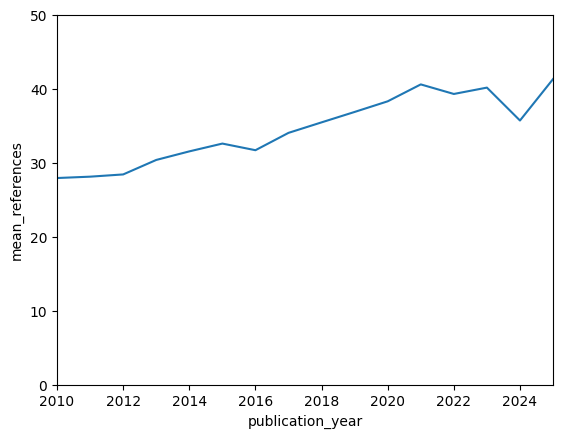

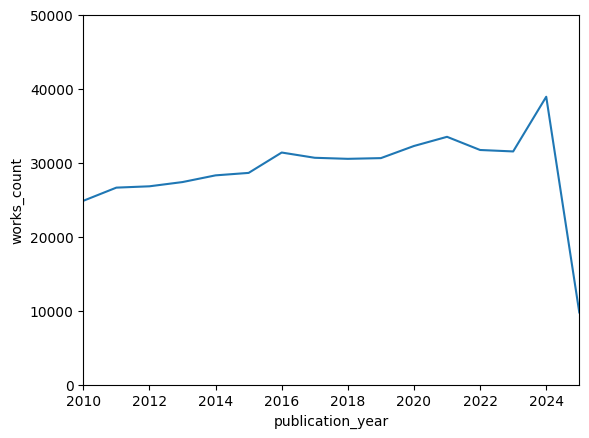

t.shape = (4, 2)
       type   count
0   article  459495
1    review    3824
2    letter     338
3  preprint      32
df.shape = (172, 3)
                             citer_id                         cited_id  weights
1163   https://openalex.org/S94499970  https://openalex.org/S175056054    12526
1171  https://openalex.org/S175056054   https://openalex.org/S94499970     8226
1178    https://openalex.org/S2876017  https://openalex.org/S149240962     5769
1182  https://openalex.org/S149240962    https://openalex.org/S5353659     4796
1183  https://openalex.org/S149240962  https://openalex.org/S170137484     4768


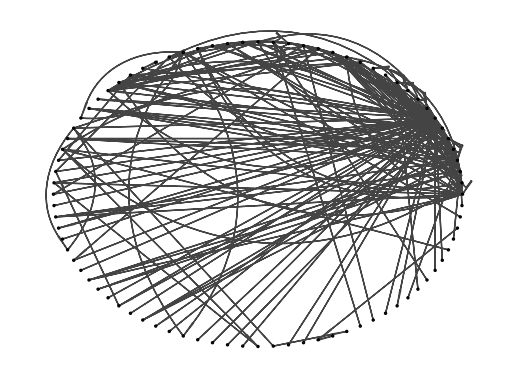

DONE!


In [35]:
if __name__ == "__main__":
    main()
    print("DONE!")